# ECGR 5106 Homework 4


Student name: Omar Mina-Blanco

Student Id: 800863713

In [ ]:
import os
import re
import math
import time
import random
import copy
import unicodedata
import urllib.request
from dataclasses import dataclass
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 42 #random seed

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.makedirs("hw4_outputs", exist_ok=True)

Device: cuda
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition


In [ ]:
from torch.profiler import profile, ProfilerActivity

try:

    from fvcore.nn import FlopCountAnalysis #for google colab
except Exception:
    FlopCountAnalysis = None


def count_parameters(model): #Count trainable parameters in a PyTorch model
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def model_size(model): #Return actual parameter memory in MB using each tensor's dtype.
    return sum(p.numel() * p.element_size() for p in model.parameters()) / (1024 ** 2)


def safe_exp(x): #compute perplexity safely from cross-entropy loss
    return float(math.exp(min(float(x), 20.0)))


def _move_nested_to_device(obj, target_device): #move tensors inside tuples or lists/dicts to device
    if torch.is_tensor(obj):
        return obj.detach().to(target_device)
    if isinstance(obj, tuple):
        return tuple(_move_nested_to_device(v, target_device) for v in obj)
    if isinstance(obj, list):
        return [_move_nested_to_device(v, target_device) for v in obj]
    if isinstance(obj, dict):
        return {k: _move_nested_to_device(v, target_device) for k, v in obj.items()}
    return obj


def profile_forward_flops(model, example_inputs, profile_device="cpu", warmup=1): #calculate FLOPs

    model_was_training = model.training
    original_device = next(model.parameters()).device
    target_device = torch.device(profile_device)

    model = model.to(target_device).eval()
    inputs = _move_nested_to_device(example_inputs, target_device)
    if not isinstance(inputs, tuple):
        inputs = (inputs,)

    with torch.no_grad():
        for _ in range(warmup):
            _ = model(*inputs)

    # PyTorch profiler automatic FLOP counting
    try:
        with profile(activities=[ProfilerActivity.CPU], with_flops=True, record_shapes=False) as prof:
            with torch.no_grad():
                _ = model(*inputs)
        flops = int(sum((evt.flops or 0) for evt in prof.key_averages()))
    except Exception as exc:
        print("PyTorch profiler FLOP calculation failed:", repr(exc))
        flops = 0

    # incase it falis
    if flops <= 0 and FlopCountAnalysis is not None:
        try:
            flops = int(FlopCountAnalysis(model, inputs).total())
        except Exception as exc:
            print("fvcore fallback FLOP calculation failed:", repr(exc))
            flops = 0

    model = model.to(original_device)
    if model_was_training:
        model.train()
    else:
        model.eval()

    return flops if flops > 0 else np.nan


def profile_char_lm_flops(model, vocab_size, seq_len): #batch size 1
    dummy_x = torch.randint(0, vocab_size, (1, int(seq_len)), dtype=torch.long)
    return profile_forward_flops(model, (dummy_x,))


def profile_translation_flops(model, loader): #Profile one translation forward pass using the first validation

    src, src_lengths, trg, trg_lengths, src_texts, trg_texts = next(iter(loader))
    dummy_src = src[:1]
    dummy_tgt_input = trg[:1, :-1]
    return profile_forward_flops(model, (dummy_src, dummy_tgt_input))


class ProfileCharRNNLM(nn.Module):

    def __init__(self, vocab_size, model_type="GRU", embedding_dim=64, hidden_size=128):
        super().__init__()
        self.model_type = model_type.upper()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        if self.model_type == "RNN":
            self.cell = nn.RNNCell(embedding_dim, hidden_size)
        elif self.model_type == "LSTM":
            self.cell = nn.LSTMCell(embedding_dim, hidden_size)
        else:
            self.cell = nn.GRUCell(embedding_dim, hidden_size)
        self.fc_out = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        batch_size, seq_len = x.shape
        h = torch.zeros(batch_size, self.hidden_size, device=x.device)
        c = torch.zeros(batch_size, self.hidden_size, device=x.device)
        logits = []
        emb = self.embedding(x)
        for t in range(seq_len):
            if self.model_type == "LSTM":
                h, c = self.cell(emb[:, t, :], (h, c))
            else:
                h = self.cell(emb[:, t, :], h)
            logits.append(self.fc_out(h))
        return torch.stack(logits, dim=1)


def profile_hw2_char_rnn_flops(model_type, vocab_size, seq_len, embedding_dim=64, hidden_size=128): #HW2 recurrent model FLOPs
    profiler_model = ProfileCharRNNLM(vocab_size, model_type=model_type, embedding_dim=embedding_dim, hidden_size=hidden_size)
    dummy_x = torch.randint(0, vocab_size, (1, int(seq_len)), dtype=torch.long)
    return profile_forward_flops(profiler_model, (dummy_x,))


class ProfileGRUTranslation(nn.Module): #GRU encoder-decoder used to profile HW3 baseline complexity

    def __init__(self, src_vocab_size, trg_vocab_size, embedding_dim=256, hidden_size=256, attention=False, pad_idx=0):
        super().__init__()
        self.hidden_size = hidden_size
        self.attention = attention
        self.src_embedding = nn.Embedding(src_vocab_size, embedding_dim, padding_idx=pad_idx)
        self.trg_embedding = nn.Embedding(trg_vocab_size, embedding_dim, padding_idx=pad_idx)
        self.encoder_cell = nn.GRUCell(embedding_dim, hidden_size)
        self.decoder_cell = nn.GRUCell(embedding_dim, hidden_size)
        self.fc_out = nn.Linear(hidden_size * 2 if attention else hidden_size, trg_vocab_size)

    def forward(self, src, tgt_input):
        batch_size = src.size(0)
        h = torch.zeros(batch_size, self.hidden_size, device=src.device)
        encoder_states = []
        src_emb = self.src_embedding(src)
        for t in range(src.size(1)):
            h = self.encoder_cell(src_emb[:, t, :], h)
            encoder_states.append(h)
        encoder_states = torch.stack(encoder_states, dim=1)

        logits = []
        tgt_emb = self.trg_embedding(tgt_input)
        for t in range(tgt_input.size(1)):
            h = self.decoder_cell(tgt_emb[:, t, :], h)
            if self.attention:
                scores = torch.bmm(encoder_states, h.unsqueeze(2)).squeeze(2)
                weights = torch.softmax(scores, dim=1)
                context = torch.bmm(weights.unsqueeze(1), encoder_states).squeeze(1)
                out_input = torch.cat([h, context], dim=1)
            else:
                out_input = h
            logits.append(self.fc_out(out_input))
        return torch.stack(logits, dim=1)


def profile_hw3_gru_translation_flops(src_vocab_size, trg_vocab_size, src_len, tgt_len, attention=False): #one GRU translation forward pass
    profiler_model = ProfileGRUTranslation(src_vocab_size, trg_vocab_size, attention=attention)
    dummy_src = torch.randint(0, src_vocab_size, (1, int(src_len)), dtype=torch.long)
    dummy_tgt = torch.randint(0, trg_vocab_size, (1, int(tgt_len)), dtype=torch.long)
    return profile_forward_flops(profiler_model, (dummy_src, dummy_tgt))


def plot_history(history, title, save_path=None):
    plt.figure(figsize=(9, 5))
    plt.plot(history["train_loss"], label="train loss")
    if "val_loss" in history:
        plt.plot(history["val_loss"], label="validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Cross Entropy Loss")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()


# Problem 1: Character-Level Transformer vs. RNN Comparison


In [ ]:
#text sequence from Homework 2.
HW2_TEXT = """Next character prediction is a fundamental task in the field of natural language processing (NLP) that involves predicting the next character in a sequence of text based on the characters that precede it. This task is essential for various applications, including text auto-completion, spell checking, and even in the development of sophisticated AI models capable of generating human-like text.
At its core, next character prediction relies on statistical models or deep learning algorithms to analyze a given sequence of text and predict which character is most likely to follow. These predictions are based on patterns and relationships learned from large datasets of text during the training phase of the model.
One of the most popular approaches to next character prediction involves the use of Recurrent Neural Networks (RNNs), and more specifically, a variant called Long Short-Term Memory (LSTM) networks. RNNs are particularly well-suited for sequential data like text, as they can maintain information in 'memory' about previous characters to inform the prediction of the next character. LSTM networks enhance this capability by being able to remember long-term dependencies, making them even more effective for next character prediction tasks.
Training a model for next character prediction involves feeding it large amounts of text data, allowing it to learn the probability of each character's appearance following a sequence of characters. During this training process, the model adjusts its parameters to minimize the difference between its predictions and the actual outcomes, thus improving its predictive accuracy over time.
Once trained, the model can be used to predict the next character in a given piece of text by considering the sequence of characters that precede it. This can enhance user experience in text editing software, improve efficiency in coding environments with auto-completion features, and enable more natural interactions with AI-based chatbots and virtual assistants.
In summary, next character prediction plays a crucial role in enhancing the capabilities of various NLP applications, making text-based interactions more efficient, accurate, and human-like. Through the use of advanced machine learning models like RNNs and LSTMs, next character prediction continues to evolve, opening new possibilities for the future of text-based technology."""

print("Text length:", len(HW2_TEXT))
print("Unique characters:", len(set(HW2_TEXT)))

Text length: 2391
Unique characters: 45


In [ ]:
#character dataset from RNN-CharDataset.py and shakespeare-loader.py.

class CharSequenceDataset(Dataset):
    def __init__(self, text, seq_len, char_to_idx=None, idx_to_char=None):
        self.text = text
        self.seq_len = seq_len
        if char_to_idx is None:
            chars = sorted(list(set(text)))
            self.char_to_idx = {ch: i for i, ch in enumerate(chars)}
            self.idx_to_char = {i: ch for ch, i in self.char_to_idx.items()}
        else:
            self.char_to_idx = char_to_idx
            self.idx_to_char = idx_to_char
        self.encoded = torch.tensor([self.char_to_idx[ch] for ch in text], dtype=torch.long)

    def __len__(self):
        return len(self.encoded) - self.seq_len

    def __getitem__(self, idx):
        x = self.encoded[idx:idx+self.seq_len]
        y = self.encoded[idx+1:idx+self.seq_len+1]
        return x, y

def make_char_loaders(text, seq_len, train_ratio=0.8, batch_size=128):
    full_ds = CharSequenceDataset(text, seq_len)
    n = len(full_ds)
    train_n = int(train_ratio * n)
    train_text = text[:train_n + seq_len]
    val_text = text[train_n:]
    train_ds = CharSequenceDataset(train_text, seq_len, full_ds.char_to_idx, full_ds.idx_to_char)
    val_ds = CharSequenceDataset(val_text, seq_len, full_ds.char_to_idx, full_ds.idx_to_char)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, full_ds.char_to_idx, full_ds.idx_to_char

In [ ]:
# Transformer character language model from transformer next-character example.

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=2048, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        if d_model % 2 == 1:
            pe[:, 1::2] = torch.cos(position * div_term[:-1])
        else:
            pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

class CharTransformerLM(nn.Module):
    def __init__(self, vocab_size, d_model=128, nhead=4, num_layers=2, dim_feedforward=256, dropout=0.1, max_len=512):
        super().__init__()
        self.vocab_size = vocab_size
        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model, max_len=max_len, dropout=dropout)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.fc_out = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        seq_len = x.size(1)
        causal_mask = torch.triu(torch.ones(seq_len, seq_len, device=x.device), diagonal=1).bool()
        x = self.embedding(x) * math.sqrt(self.d_model)
        x = self.pos_encoder(x)
        h = self.transformer(x, mask=causal_mask)
        return self.fc_out(h)


In [ ]:
def train_char_model(model, train_loader, val_loader, epochs=40, lr=1e-3):
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    history = {"train_loss": [], "val_loss": [], "val_acc": []}
    start = time.perf_counter()
    for epoch in range(epochs):
        model.train()
        total_loss, total_tokens = 0.0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad(set_to_none=True)
            logits = model(x)
            loss = criterion(logits.reshape(-1, logits.size(-1)), y.reshape(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item() * y.numel()
            total_tokens += y.numel()
        train_loss = total_loss / max(1, total_tokens)
        val_loss, val_acc = evaluate_char_model(model, val_loader)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        if (epoch + 1) % max(1, epochs // 5) == 0:
            print(f"Epoch {epoch+1:03d}/{epochs} | train {train_loss:.4f} | val {val_loss:.4f} | val acc {val_acc:.4f}")
    return history, time.perf_counter() - start

@torch.no_grad()
def evaluate_char_model(model, loader):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    total_loss, total_correct, total_tokens = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits.reshape(-1, logits.size(-1)), y.reshape(-1))
        pred = logits.argmax(dim=-1)
        total_loss += loss.item() * y.numel()
        total_correct += (pred == y).sum().item()
        total_tokens += y.numel()
    return total_loss / max(1, total_tokens), total_correct / max(1, total_tokens)

@torch.no_grad()
def generate_char_text(model, start_text, char_to_idx, idx_to_char, length=200, temperature=0.8):
    model.eval()
    generated = start_text
    for _ in range(length):
        x = torch.tensor([[char_to_idx[ch] for ch in generated[-128:] if ch in char_to_idx]], dtype=torch.long, device=device)
        logits = model(x)[:, -1, :] / max(temperature, 1e-6)
        probs = torch.softmax(logits, dim=-1)
        next_idx = torch.multinomial(probs, num_samples=1).item()
        generated += idx_to_char[next_idx]
    return generated


Problem 1 Transformer, sequence length = 10
Epoch 008/40 | train 1.7086 | val 2.2635 | val acc 0.3864
Epoch 016/40 | train 1.3795 | val 2.3388 | val acc 0.4071
Epoch 024/40 | train 1.1959 | val 2.4691 | val acc 0.4176
Epoch 032/40 | train 1.0785 | val 2.6075 | val acc 0.4298
Epoch 040/40 | train 0.9803 | val 2.6602 | val acc 0.4342


/usr/local/lib/python3.12/dist-packages/torch/profiler/profiler.py:224: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(


Next ed chors apat ate patict toctoulictovedinviofof wedict ich ict olllllllllllllllllllllllllllllllllllllllh formarllllor Lr orllllllowearech wede ch ch ch cth mare nes the h athe arke inel-Te ine thene m

Problem 1 Transformer, sequence length = 20
Epoch 008/40 | train 1.6972 | val 2.3193 | val acc 0.3555
Epoch 016/40 | train 1.2727 | val 2.5313 | val acc 0.3841
Epoch 024/40 | train 1.0402 | val 2.8135 | val acc 0.3894
Epoch 032/40 | train 0.8714 | val 3.0023 | val acc 0.3946
Epoch 040/40 | train 0.7723 | val 3.1696 | val acc 0.4047
Next character. LSTM networ. Dura predictictineng ting thices te thinve tha thine t th thinve the thithe thace thas thacthine the thinvice the tane t. tor thext cer car cher cher cars mpr cecededer cis cis

Problem 1 Transformer, sequence length = 30
Epoch 008/40 | train 1.7306 | val 2.4711 | val acc 0.3163
Epoch 016/40 | train 1.2252 | val 2.6934 | val acc 0.3421
Epoch 024/40 | train 0.9627 | val 3.0000 | val acc 0.3580
Epoch 032/40 | train 0.8144 | val 

,problem,model,seq_len,train_loss,val_loss,val_accuracy,val_perplexity,training_time_s,inference_time_s,params,model_size,flops_forward_per_sequence,sample_output
0,P1,Transformer LM,10,0.980275,2.660153,0.434172,14.298476,1.594927,0.115186,276525,1.054859,4152320,Next ed chors apat ate patict toctoulictovedin...
1,P1,Transformer LM,20,0.772268,3.169593,0.404737,23.797800,1.801046,0.116696,276525,1.054859,8509440,Next character. LSTM networ. Dura predictictin...
2,P1,Transformer LM,30,0.716459,3.382012,0.368710,29.429927,1.891629,0.116948,276525,1.054859,13071360,"Next Neural Networks (RNs), and s), and more s..."


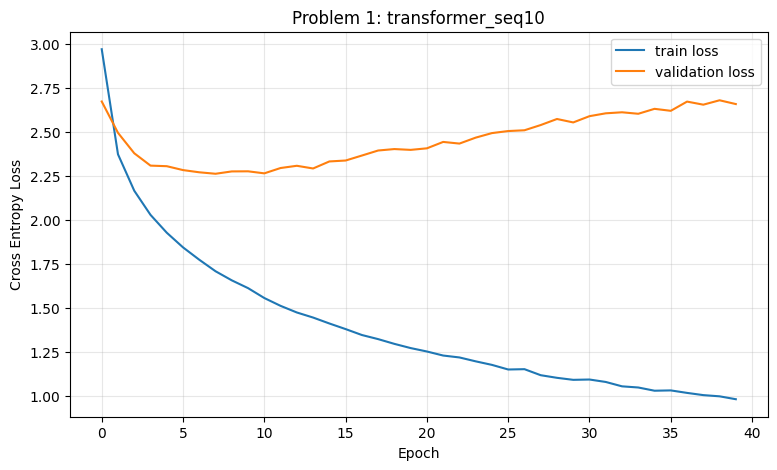

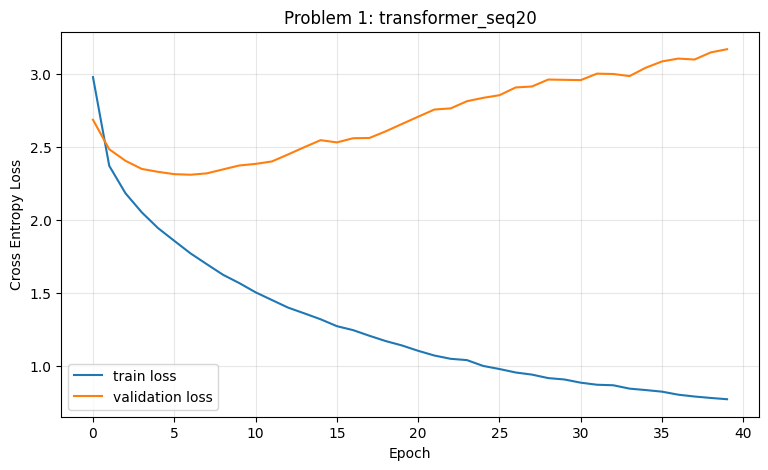

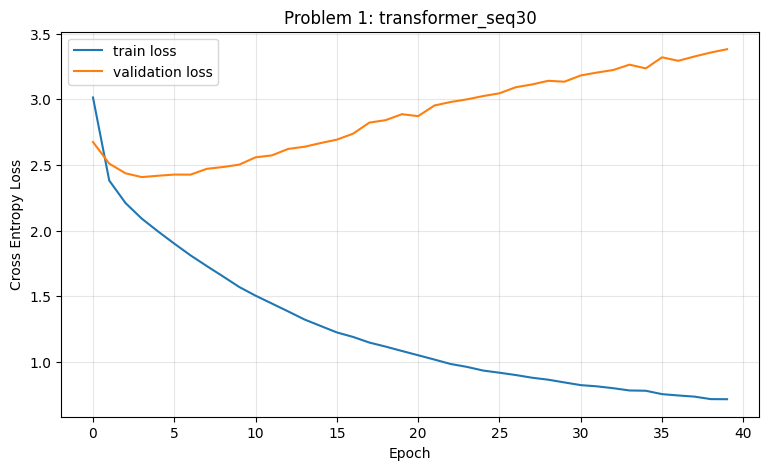

In [ ]:
P1_EPOCHS = 40 #more epocks increased training time a lot
P1_BATCH_SIZE = 128 #128 for A100 gou
P1_SEQ_LENS = [10, 20, 30] #increasing sequence lengths

p1_results = []
p1_histories = {}

for seq_len in P1_SEQ_LENS:
    print("\n" + "="*80)
    print(f"Problem 1 Transformer, sequence length = {seq_len}")

    # Builds new dataset for each sequence length
    train_loader, val_loader, char_to_idx, idx_to_char = make_char_loaders(HW2_TEXT, seq_len, batch_size=P1_BATCH_SIZE)
    vocab_size = len(char_to_idx)

    # Baseline Transformer LM

    model = CharTransformerLM(vocab_size, d_model=128, nhead=4, num_layers=2, dim_feedforward=256, dropout=0.1, max_len=128)


    history, train_time = train_char_model(model, train_loader, val_loader, epochs=P1_EPOCHS, lr=1e-3)
    val_loss, val_acc = evaluate_char_model(model, val_loader)

    # Inference time
    t0 = time.perf_counter()
    sample = generate_char_text(model, "Next ", char_to_idx, idx_to_char, length=200, temperature=0.8)
    inference_time = time.perf_counter() - t0


    flops_forward = profile_char_lm_flops(model, vocab_size, seq_len)

    p1_histories[f"transformer_seq{seq_len}"] = history
    p1_results.append({
        "problem": "P1", "model": "Transformer LM", "seq_len": seq_len,
        "train_loss": history["train_loss"][-1], "val_loss": val_loss, "val_accuracy": val_acc,
        "val_perplexity": safe_exp(val_loss), "training_time_s": train_time,
        "inference_time_s": inference_time, "params": count_parameters(model),
        "model_size": model_size(model),
        "flops_forward_per_sequence": flops_forward,
        "sample_output": sample,
    })
    print(sample)

p1_results_df = pd.DataFrame(p1_results)
display(p1_results_df)
p1_results_df.to_csv("hw4_outputs/problem1_transformer_results.csv", index=False)

for key, hist in p1_histories.items():
    plot_history(hist, title=f"Problem 1: {key}", save_path=f"hw4_outputs/{key}_loss.png")

In [ ]:
# Homework 2 RNN reference table
P1_HW2_VOCAB = len(set(HW2_TEXT))

hw2_rnn_reference = pd.DataFrame([
    {"source": "HW2", "model": "RNN", "seq_len": 10, "train_loss": 0.492916, "val_loss": 2.909666, "val_accuracy": 0.471130, "val_perplexity": 18.350663, "training_time_s": 14.902384, "inference_time_s": 0.069107, "params": 33517, "model_size": 0.127857},
    {"source": "HW2", "model": "LSTM", "seq_len": 10, "train_loss": 0.476045, "val_loss": 2.788582, "val_accuracy": 0.476151, "val_perplexity": 16.257943, "training_time_s": 16.340004, "inference_time_s": 0.074679, "params": 108013, "model_size": 0.412037},
    {"source": "HW2", "model": "GRU", "seq_len": 10, "train_loss": 0.465358, "val_loss": 3.002826, "val_accuracy": 0.488494, "val_perplexity": 20.142388, "training_time_s": 16.219200, "inference_time_s": 0.074567, "params": 83181, "model_size": 0.317310},
    {"source": "HW2", "model": "RNN", "seq_len": 20, "train_loss": 0.261957, "val_loss": 3.257714, "val_accuracy": 0.497803, "val_perplexity": 25.990052, "training_time_s": 15.708730, "inference_time_s": 0.070540, "params": 33517, "model_size": 0.127857},
    {"source": "HW2", "model": "LSTM", "seq_len": 20, "train_loss": 0.251344, "val_loss": 3.075810, "val_accuracy": 0.480335, "val_perplexity": 21.667426, "training_time_s": 16.304992, "inference_time_s": 0.076080, "params": 108013, "model_size": 0.412037},
    {"source": "HW2", "model": "GRU", "seq_len": 20, "train_loss": 0.243505, "val_loss": 3.067938, "val_accuracy": 0.509623, "val_perplexity": 21.497532, "training_time_s": 16.235233, "inference_time_s": 0.073663, "params": 83181, "model_size": 0.317310},
    {"source": "HW2", "model": "RNN", "seq_len": 30, "train_loss": 0.179242, "val_loss": 3.259384, "val_accuracy": 0.475244, "val_perplexity": 26.033486, "training_time_s": 16.084707, "inference_time_s": 0.074459, "params": 33517, "model_size": 0.127857},
    {"source": "HW2", "model": "LSTM", "seq_len": 30, "train_loss": 0.174122, "val_loss": 3.027241, "val_accuracy": 0.495467, "val_perplexity": 20.640200, "training_time_s": 16.724085, "inference_time_s": 0.075475, "params": 108013, "model_size": 0.412037},
    {"source": "HW2", "model": "GRU", "seq_len": 30, "train_loss": 0.164701, "val_loss": 3.254836, "val_accuracy": 0.498605, "val_perplexity": 25.915362, "training_time_s": 16.453324, "inference_time_s": 0.074797, "params": 83181, "model_size": 0.317310},
])


hw2_rnn_reference["flops_forward_per_sequence"] = hw2_rnn_reference.apply(
    lambda row: profile_hw2_char_rnn_flops(row["model"], P1_HW2_VOCAB, row["seq_len"], embedding_dim=64, hidden_size=128),
    axis=1,
)

p1_compare = pd.concat([
    hw2_rnn_reference,
    p1_results_df.assign(source="HW4")[["source", "model", "seq_len", "train_loss", "val_loss", "val_accuracy", "val_perplexity", "training_time_s", "inference_time_s", "params", "model_size", "flops_forward_per_sequence"]]
], ignore_index=True)

display(p1_compare.sort_values(["seq_len", "model"]))
p1_compare.to_csv("hw4_outputs/problem1_hw2_comparison_with_flops.csv", index=False)


,source,model,seq_len,train_loss,val_loss,val_accuracy,val_perplexity,training_time_s,inference_time_s,params,model_size,flops_forward_per_sequence
2,HW2,GRU,10,0.465358,3.002826,0.488494,20.142388,16.219200,0.074567,83181,0.317310,1591040
1,HW2,LSTM,10,0.476045,2.788582,0.476151,16.257943,16.340004,0.074679,108013,0.412037,2085120
0,HW2,RNN,10,0.492916,2.909666,0.471130,18.350663,14.902384,0.069107,33517,0.127857,606720
9,HW4,Transformer LM,10,0.980275,2.660153,0.434172,14.298476,1.594927,0.115186,276525,1.054859,4152320
5,HW2,GRU,20,0.243505,3.067938,0.509623,21.497532,16.235233,0.073663,83181,0.317310,3182080
4,HW2,LSTM,20,0.251344,3.075810,0.480335,21.667426,16.304992,0.076080,108013,0.412037,4170240
3,HW2,RNN,20,0.261957,3.257714,0.497803,25.990052,15.708730,0.070540,33517,0.127857,1213440
10,HW4,Transformer LM,20,0.772268,3.169593,0.404737,23.797800,1.801046,0.116696,276525,1.054859,8509440
8,HW2,GRU,30,0.164701,3.254836,0.498605,25.915362,16.453324,0.074797,83181,0.317310,4773120
7,HW2,LSTM,30,0.174122,3.027241,0.495467,20.640200,16.724085,0.075475,108013,0.412037,6255360


# Problem 2: Transformer for Character Prediction on Tiny Shakespeare


In [ ]:
# Tiny Shakespeare loader from shakespeare-loader.py.
TINY_SHAKESPEARE_PATH = "tiny_shakespeare.txt"

def download_tiny_shakespeare(path=TINY_SHAKESPEARE_PATH):
    """Download and return the full tiny Shakespeare corpus."""
    if not os.path.exists(path):
        url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
        print("Downloading tiny Shakespeare...")
        urllib.request.urlretrieve(url, path)
    with open(path, "r", encoding="utf-8") as f:
        return f.read()

tiny_text = download_tiny_shakespeare()
tiny_text_used = tiny_text  # Full dataset



Tiny Shakespeare length: 1115394
Unique characters: 65


In [ ]:
P2_EPOCHS = 8 #many transformer configuration, lower for faster completion
P2_BATCH_SIZE = 256 #longer text compared to problem 1, larger size

def run_tiny_transformer_experiment(seq_len, d_model=128, nhead=2, num_layers=2, epochs=P2_EPOCHS, label=None):
    """Train one tiny Shakespeare Transformer LM and return all required metrics."""
    label = label or f"seq{seq_len}_d{d_model}_h{nhead}_L{num_layers}"

    train_loader, val_loader, char_to_idx, idx_to_char = make_char_loaders(tiny_text_used, seq_len, batch_size=P2_BATCH_SIZE)
    vocab_size = len(char_to_idx)

    #Set max_len=128 for sliding window
    model = CharTransformerLM(vocab_size, d_model=d_model, nhead=nhead, num_layers=num_layers, dim_feedforward=4*d_model, dropout=0.1, max_len=128)


    history, train_time = train_char_model(model, train_loader, val_loader, epochs=epochs, lr=1e-3) # Train, validate time.
    val_loss, val_acc = evaluate_char_model(model, val_loader)

    # Output sequence
    t0 = time.perf_counter()
    sample = generate_char_text(model, "ROMEO:\n", char_to_idx, idx_to_char, length=300, temperature=0.8)
    inference_time = time.perf_counter() - t0

    flops_forward = profile_char_lm_flops(model, vocab_size, seq_len)

    result = {
        "problem": "P2", "label": label, "model": "Transformer LM", "seq_len": seq_len,
        "d_model": d_model, "num_heads": nhead, "num_blocks": num_layers,
        "train_loss": history["train_loss"][-1], "val_loss": val_loss,
        "val_accuracy": val_acc, "val_perplexity": safe_exp(val_loss),
        "training_time_s": train_time, "inference_time_s": inference_time,
        "params": count_parameters(model), "model_size": model_size(model),
        "flops_forward_per_sequence": flops_forward,
        "sample_output": sample,
        "sample_output_preview": sample.replace("\n", " ")[:300],
    }
    return result, history, model

In [ ]:
# 2 blocks, 2 heads for sequence lengths 20 and 30.
p2_results = []
p2_histories = {}

for seq_len in [20, 30]:
    print("\n" + "="*80)
    result, history, model = run_tiny_transformer_experiment(seq_len, d_model=128, nhead=2, num_layers=2, label=f"start_seq{seq_len}_L2_H2")
    p2_results.append(result)
    p2_histories[result["label"]] = history

p2_start_df = pd.DataFrame(p2_results)
display(p2_start_df)
p2_start_df.to_csv("hw4_outputs/problem2_starting_config_results.csv", index=False)


Epoch 001/8 | train 2.1199 | val 1.9867 | val acc 0.4202
Epoch 002/8 | train 1.8715 | val 1.9114 | val acc 0.4433
Epoch 003/8 | train 1.8009 | val 1.8852 | val acc 0.4529
Epoch 004/8 | train 1.7653 | val 1.8674 | val acc 0.4577
Epoch 005/8 | train 1.7426 | val 1.8551 | val acc 0.4628
Epoch 006/8 | train 1.7241 | val 1.8396 | val acc 0.4670
Epoch 007/8 | train 1.7096 | val 1.8461 | val acc 0.4687
Epoch 008/8 | train 1.6981 | val 1.8345 | val acc 0.4695

Epoch 001/8 | train 2.1436 | val 1.9874 | val acc 0.4214
Epoch 002/8 | train 1.8576 | val 1.8918 | val acc 0.4494
Epoch 003/8 | train 1.7820 | val 1.8595 | val acc 0.4605
Epoch 004/8 | train 1.7383 | val 1.8293 | val acc 0.4703
Epoch 005/8 | train 1.7089 | val 1.8231 | val acc 0.4737
Epoch 006/8 | train 1.6902 | val 1.8171 | val acc 0.4764
Epoch 007/8 | train 1.6759 | val 1.8100 | val acc 0.4767
Epoch 008/8 | train 1.6632 | val 1.8006 | val acc 0.4801


,problem,label,model,seq_len,d_model,num_heads,num_blocks,train_loss,val_loss,val_accuracy,val_perplexity,training_time_s,inference_time_s,params,model_size,flops_forward_per_sequence,sample_output,sample_output_preview
0,P2,start_seq20_L2_H2,Transformer LM,20,128,2,2,1.698137,1.834461,0.469458,6.261760,100.551593,0.18743,413249,1.57642,11233280,ROMEO:\nI am not my not he heasinoureweathe.\n...,ROMEO: I am not my not he heasinoureweathe. A ...
1,P2,start_seq30_L2_H2,Transformer LM,30,128,2,2,1.663155,1.800556,0.480088,6.053012,109.068587,0.17550,413249,1.57642,17157120,"ROMEO:\nA good I die? why, they mans ge, hinof...","ROMEO: A good I die? why, they mans ge, hinofr..."


In [ ]:
# Hyperparameter sweep 30 sequence length
p2_grid = [
    {"num_blocks": 1, "num_heads": 2, "d_model": 128},
    {"num_blocks": 1, "num_heads": 4, "d_model": 128},
    {"num_blocks": 2, "num_heads": 2, "d_model": 128},
    {"num_blocks": 2, "num_heads": 4, "d_model": 128},
    {"num_blocks": 4, "num_heads": 2, "d_model": 128},
    {"num_blocks": 4, "num_heads": 4, "d_model": 128},
    {"num_blocks": 2, "num_heads": 4, "d_model": 256},
    {"num_blocks": 4, "num_heads": 4, "d_model": 256},
]

p2_sweep_results = []
p2_sweep_histories = {}

for cfg2 in p2_grid:
    label = f"seq30_L{cfg2['num_blocks']}_H{cfg2['num_heads']}_D{cfg2['d_model']}"
    print("\n" + "="*80)
    print("Problem 2 sweep:", label)
    result, history, model = run_tiny_transformer_experiment(30, d_model=cfg2["d_model"], nhead=cfg2["num_heads"], num_layers=cfg2["num_blocks"], epochs=P2_EPOCHS, label=label)
    p2_sweep_results.append(result)
    p2_sweep_histories[label] = history

p2_sweep_df = pd.DataFrame(p2_sweep_results).sort_values("val_accuracy", ascending=False)
display(p2_sweep_df)
p2_sweep_df.to_csv("hw4_outputs/problem2_hyperparameter_sweep.csv", index=False)


Problem 2 sweep: seq30_L1_H2_D128
Epoch 001/8 | train 2.3801 | val 2.4115 | val acc 0.2904
Epoch 002/8 | train 2.3177 | val 2.4115 | val acc 0.2939
Epoch 003/8 | train 2.3006 | val 2.4122 | val acc 0.2950
Epoch 004/8 | train 2.2919 | val 2.4027 | val acc 0.2973
Epoch 005/8 | train 2.2859 | val 2.3941 | val acc 0.3004
Epoch 006/8 | train 2.2813 | val 2.3962 | val acc 0.3023
Epoch 007/8 | train 2.2763 | val 2.3860 | val acc 0.3038
Epoch 008/8 | train 2.2713 | val 2.3803 | val acc 0.3076

Problem 2 sweep: seq30_L1_H4_D128
Epoch 001/8 | train 2.3474 | val 2.3908 | val acc 0.3020
Epoch 002/8 | train 2.2754 | val 2.3708 | val acc 0.3079
Epoch 003/8 | train 2.2589 | val 2.3665 | val acc 0.3101
Epoch 004/8 | train 2.2480 | val 2.3587 | val acc 0.3135
Epoch 005/8 | train 2.2387 | val 2.3534 | val acc 0.3166
Epoch 006/8 | train 2.2284 | val 2.3300 | val acc 0.3229
Epoch 007/8 | train 2.2105 | val 2.3066 | val acc 0.3324
Epoch 008/8 | train 2.1839 | val 2.2697 | val acc 0.3444

Problem 2 sweep: 

,problem,label,model,seq_len,d_model,num_heads,num_blocks,train_loss,val_loss,val_accuracy,val_perplexity,training_time_s,inference_time_s,params,model_size,flops_forward_per_sequence,sample_output,sample_output_preview
7,P2,seq30_L4_H4_D256,Transformer LM,30,256,4,4,1.297080,1.742288,0.528970,5.710395,245.463422,0.257715,3192385,12.177982,130529280,ROMEO:\nYou have pray'd to thy provy totherirt...,ROMEO: You have pray'd to thy provy totherirto...
5,P2,seq30_L4_H4_D128,Transformer LM,30,128,4,4,1.424973,1.678991,0.523786,5.360147,173.712277,0.254534,809793,3.089115,33807360,"ROMEO:\nI lay by, and having.\nO, if n anourev...","ROMEO: I lay by, and having. O, if n anourevea..."
4,P2,seq30_L4_H2_D128,Transformer LM,30,128,2,4,1.440678,1.663158,0.522156,5.275946,170.949072,0.253715,809793,3.089115,33807360,ROMEO:\nHere is not as it is hold mathe deatha...,ROMEO: Here is not as it is hold mathe deathan...
6,P2,seq30_L2_H4_D256,Transformer LM,30,256,4,2,1.533675,1.785066,0.498410,5.959973,145.052480,0.199226,1612865,6.152592,65771520,ROMEO:\nIs am any these woord with arithonofou...,ROMEO: Is am any these woord with arithonofour...
3,P2,seq30_L2_H4_D128,Transformer LM,30,128,4,2,1.627669,1.786163,0.483932,5.966515,112.786343,0.174031,413249,1.576420,17157120,"ROMEO:\nThy arth, will say do for henorireminu...","ROMEO: Thy arth, will say do for henorireminug..."
2,P2,seq30_L2_H2_D128,Transformer LM,30,128,2,2,1.664223,1.813545,0.478236,6.132148,111.065374,0.174441,413249,1.576420,17157120,"ROMEO:\nTheir before fearewell, scaleleanderea...","ROMEO: Their before fearewell, scaleleanderear..."
1,P2,seq30_L1_H4_D128,Transformer LM,30,128,4,1,2.183904,2.269738,0.344367,9.676862,79.685264,0.134363,214977,0.820072,8832000,ROMEO:\nNay gought theant lllieainde Whire ath...,ROMEO: Nay gought theant lllieainde Whire athe...
0,P2,seq30_L1_H2_D128,Transformer LM,30,128,2,1,2.271272,2.380312,0.307586,10.808278,77.531906,0.132836,214977,0.820072,8832000,"ROMEO:\nFordom the LO:\nLore here thathe, w y ...","ROMEO: Fordom the LO: Lore here thathe, w y st..."


In [ ]:
# Output sequence comparison
p2_output_comparison_df = p2_sweep_df[[
    "label", "seq_len", "num_blocks", "num_heads", "d_model",
    "val_loss", "val_accuracy", "val_perplexity", "inference_time_s",
    "flops_forward_per_sequence", "params", "sample_output_preview"
]].copy()

display(p2_output_comparison_df)
p2_output_comparison_df.to_csv("hw4_outputs/problem2_output_sequence_comparison.csv", index=False)


,label,seq_len,num_blocks,num_heads,d_model,val_loss,val_accuracy,val_perplexity,inference_time_s,flops_forward_per_sequence,params,sample_output_preview
7,seq30_L4_H4_D256,30,4,4,256,1.742288,0.528970,5.710395,0.257715,130529280,3192385,ROMEO: You have pray'd to thy provy totherirto...
5,seq30_L4_H4_D128,30,4,4,128,1.678991,0.523786,5.360147,0.254534,33807360,809793,"ROMEO: I lay by, and having. O, if n anourevea..."
4,seq30_L4_H2_D128,30,4,2,128,1.663158,0.522156,5.275946,0.253715,33807360,809793,ROMEO: Here is not as it is hold mathe deathan...
6,seq30_L2_H4_D256,30,2,4,256,1.785066,0.498410,5.959973,0.199226,65771520,1612865,ROMEO: Is am any these woord with arithonofour...
3,seq30_L2_H4_D128,30,2,4,128,1.786163,0.483932,5.966515,0.174031,17157120,413249,"ROMEO: Thy arth, will say do for henorireminug..."
2,seq30_L2_H2_D128,30,2,2,128,1.813545,0.478236,6.132148,0.174441,17157120,413249,"ROMEO: Their before fearewell, scaleleanderear..."
1,seq30_L1_H4_D128,30,1,4,128,2.269738,0.344367,9.676862,0.134363,8832000,214977,ROMEO: Nay gought theant lllieainde Whire athe...
0,seq30_L1_H2_D128,30,1,2,128,2.380312,0.307586,10.808278,0.132836,8832000,214977,"ROMEO: Fordom the LO: Lore here thathe, w y st..."


In [ ]:
# Sequence length 50
best_p2_cfg = p2_sweep_df.iloc[0].to_dict()
print("Best P2 config used for seq_len=50:")
print(best_p2_cfg)

p2_seq50_result, p2_seq50_history, p2_seq50_model = run_tiny_transformer_experiment(
    seq_len=50,
    d_model=int(best_p2_cfg["d_model"]),
    nhead=int(best_p2_cfg["num_heads"]),
    num_layers=int(best_p2_cfg["num_blocks"]),
    epochs=P2_EPOCHS,
    label="seq50_best_config",
)

p2_seq50_df = pd.DataFrame([p2_seq50_result])
display(p2_seq50_df)
p2_seq50_df.to_csv("hw4_outputs/problem2_seq50_results.csv", index=False)

Best P2 config used for seq_len=50:
{'problem': 'P2', 'label': 'seq30_L4_H4_D256', 'model': 'Transformer LM', 'seq_len': 30, 'd_model': 256, 'num_heads': 4, 'num_blocks': 4, 'train_loss': 1.2970797209609715, 'val_loss': 1.7422881774230543, 'val_accuracy': 0.5289695899249722, 'val_perplexity': 5.710394881595438, 'training_time_s': 245.46342211699994, 'inference_time_s': 0.2577152889998615, 'params': 3192385, 'model_size': 12.177982330322266, 'flops_forward_per_sequence': 130529280, 'sample_output': "ROMEO:\nYou have pray'd to thy provy totherirton totot, tonge, thillllerowowert\nWen d ithillllllllll's howows ows cks s t, ow bowin, I ooockine ome fut it.\nSt I it ald Rome we he me th s anomeveve anor ak inorche bort\nT: we thowithe he, I I thenorithere anoume poree che he the the\nTher\nTofoncer ither or her", 'sample_output_preview': "ROMEO: You have pray'd to thy provy totherirton totot, tonge, thillllerowowert Wen d ithillllllllll's howows ows cks s t, ow bowin, I ooockine ome fut it.

,problem,label,model,seq_len,d_model,num_heads,num_blocks,train_loss,val_loss,val_accuracy,val_perplexity,training_time_s,inference_time_s,params,model_size,flops_forward_per_sequence,sample_output,sample_output_preview
0,P2,seq50_best_config,Transformer LM,50,256,4,4,1.18511,1.75827,0.537722,5.802393,345.358621,0.257009,3192385,12.177982,221644800,"ROMEO:\nFather, my lord; I hear him speak.\nNo...","ROMEO: Father, my lord; I hear him speak. Now,..."


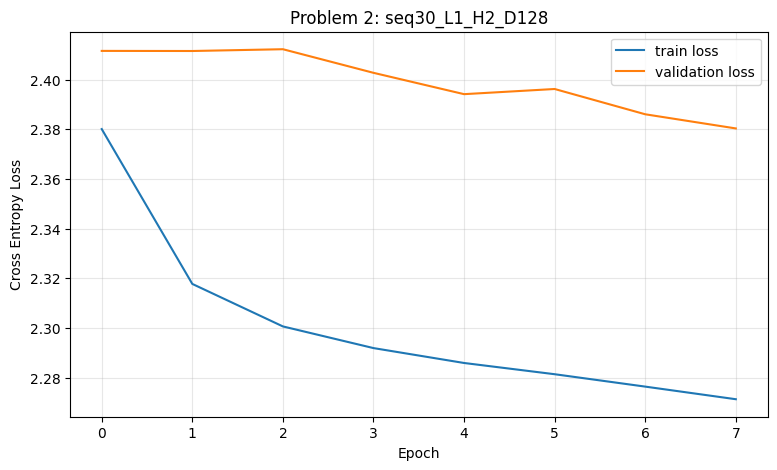

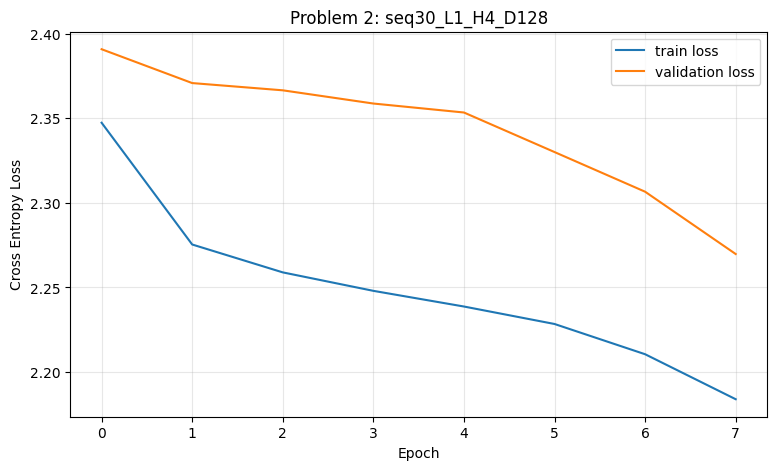

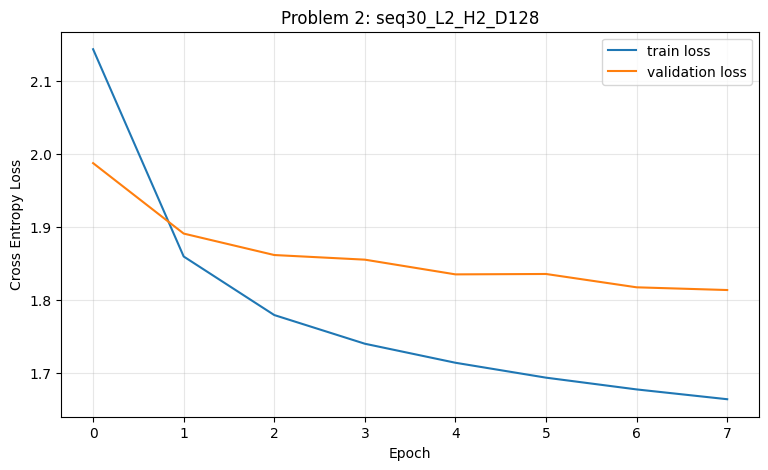

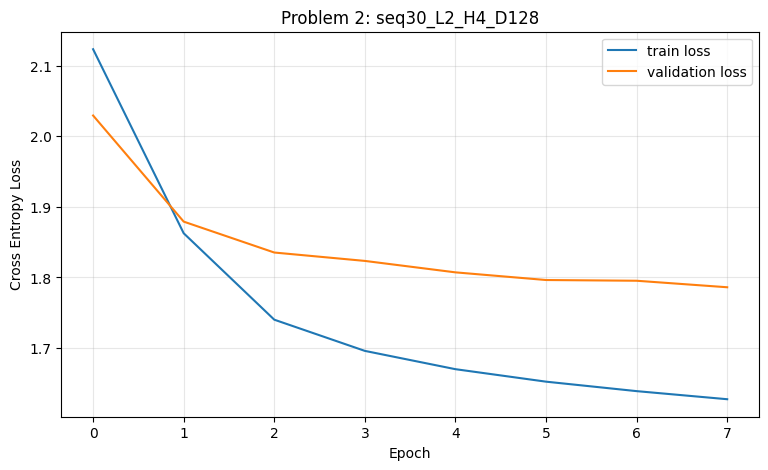

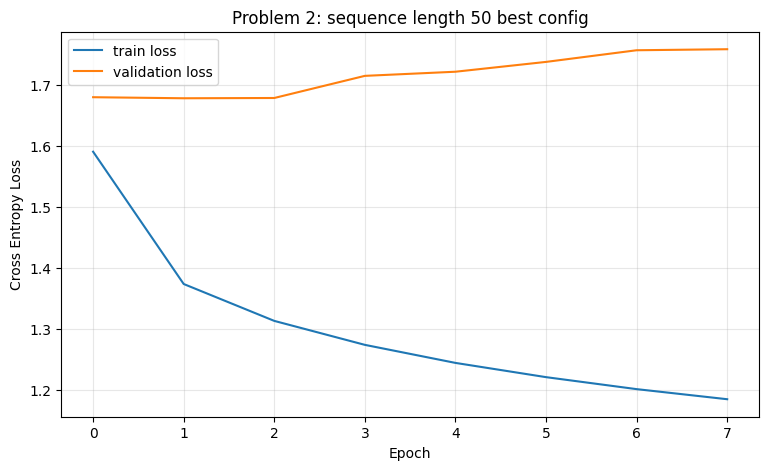

,source,model,seq_len,train_loss,val_loss,val_accuracy,val_perplexity,training_time_s,inference_time_s,params,model_size,flops_forward_per_sequence,problem,sample_output_preview
0,HW2,LSTM,20,1.266617,1.819538,0.505975,6.169007,70.140774,0.478664,111294,0.424553,4272640,HW2 RNN reference,NaN
1,HW2,GRU,20,1.313177,1.781781,0.508892,5.940428,69.053861,0.507630,86462,0.329826,3284480,HW2 RNN reference,NaN
2,HW2,LSTM,30,1.178834,1.882417,0.507440,6.569365,69.984428,0.477316,111294,0.424553,6408960,HW2 RNN reference,NaN
3,HW2,GRU,30,1.240138,1.831439,0.510139,6.242862,69.189161,0.499982,86462,0.329826,4926720,HW2 RNN reference,NaN
4,HW2,LSTM,50,1.088590,1.978978,0.500123,7.235344,71.049851,0.518056,111294,0.424553,10681600,HW2 RNN reference,NaN
5,HW2,GRU,50,1.172032,1.892163,0.506706,6.633700,71.042900,0.445832,86462,0.329826,8211200,HW2 RNN reference,NaN
6,NaN,Transformer LM,20,1.698137,1.834461,0.469458,6.261760,100.551593,0.187430,413249,1.576420,11233280,HW4 Transformer,ROMEO: I am not my not he heasinoureweathe. A ...
7,NaN,Transformer LM,30,1.663155,1.800556,0.480088,6.053012,109.068587,0.175500,413249,1.576420,17157120,HW4 Transformer,"ROMEO: A good I die? why, they mans ge, hinofr..."
8,NaN,Transformer LM,30,1.297080,1.742288,0.528970,5.710395,245.463422,0.257715,3192385,12.177982,130529280,HW4 Transformer,ROMEO: You have pray'd to thy provy totherirto...
9,NaN,Transformer LM,30,1.424973,1.678991,0.523786,5.360147,173.712277,0.254534,809793,3.089115,33807360,HW4 Transformer,"ROMEO: I lay by, and having. O, if n anourevea..."


In [ ]:
for key in list(p2_sweep_histories.keys())[:4]:
    plot_history(p2_sweep_histories[key], title=f"Problem 2: {key}", save_path=f"hw4_outputs/problem2_{key}_loss.png")
plot_history(p2_seq50_history, title="Problem 2: sequence length 50 best config", save_path="hw4_outputs/problem2_seq50_loss.png")

# Homework 2 tiny Shakespeare RNN reference values

TINY_HW2_VOCAB = len(set(tiny_text_used))
hw2_tiny_reference = pd.DataFrame([
    {"source": "HW2", "model": "LSTM", "seq_len": 20, "train_loss": 1.266617, "val_loss": 1.819538, "val_accuracy": 0.505975, "val_perplexity": 6.169007, "training_time_s": 70.140774, "inference_time_s": 0.478664, "params": 111294, "model_size": 0.424553},
    {"source": "HW2", "model": "GRU", "seq_len": 20, "train_loss": 1.313177, "val_loss": 1.781781, "val_accuracy": 0.508892, "val_perplexity": 5.940428, "training_time_s": 69.053861, "inference_time_s": 0.507630, "params": 86462, "model_size": 0.329826},
    {"source": "HW2", "model": "LSTM", "seq_len": 30, "train_loss": 1.178834, "val_loss": 1.882417, "val_accuracy": 0.507440, "val_perplexity": 6.569365, "training_time_s": 69.984428, "inference_time_s": 0.477316, "params": 111294, "model_size": 0.424553},
    {"source": "HW2", "model": "GRU", "seq_len": 30, "train_loss": 1.240138, "val_loss": 1.831439, "val_accuracy": 0.510139, "val_perplexity": 6.242862, "training_time_s": 69.189161, "inference_time_s": 0.499982, "params": 86462, "model_size": 0.329826},
    {"source": "HW2", "model": "LSTM", "seq_len": 50, "train_loss": 1.088590, "val_loss": 1.978978, "val_accuracy": 0.500123, "val_perplexity": 7.235344, "training_time_s": 71.049851, "inference_time_s": 0.518056, "params": 111294, "model_size": 0.424553},
    {"source": "HW2", "model": "GRU", "seq_len": 50, "train_loss": 1.172032, "val_loss": 1.892163, "val_accuracy": 0.506706, "val_perplexity": 6.633700, "training_time_s": 71.042900, "inference_time_s": 0.445832, "params": 86462, "model_size": 0.329826},
])

hw2_tiny_reference["flops_forward_per_sequence"] = hw2_tiny_reference.apply(
    lambda row: profile_hw2_char_rnn_flops(row["model"], TINY_HW2_VOCAB, row["seq_len"], embedding_dim=64, hidden_size=128),
    axis=1,
)

p2_transformer_all = pd.concat([p2_start_df, p2_sweep_df, p2_seq50_df], ignore_index=True)
p2_compare = pd.concat([
    hw2_tiny_reference.assign(problem="HW2 RNN reference"),
    p2_transformer_all.assign(problem="HW4 Transformer")[["problem", "model", "seq_len", "train_loss", "val_loss", "val_accuracy", "val_perplexity", "training_time_s", "inference_time_s", "params", "model_size", "flops_forward_per_sequence", "sample_output_preview"]]
], ignore_index=True, sort=False)

display(p2_compare)
p2_compare.to_csv("hw4_outputs/problem2_hw2_comparison_with_flops_and_outputs.csv", index=False)


# Problem 3: Transformer-Based Encoder-Decoder for English-to-French Translation


In [ ]:
from google.colab import drive

PAD_TOKEN = "<pad>"
SOS_TOKEN = "<sos>"
EOS_TOKEN = "<eos>"
UNK_TOKEN = "<unk>"
PAD_IDX, SOS_IDX, EOS_IDX, UNK_IDX = 0, 1, 2, 3

@dataclass
class TranslationConfig:
    # my path on google drive
    dataset_path: str = "/content/drive/MyDrive/data/vast_english_french.txt"
    train_ratio: float = 0.80
    min_freq: int = 1
    max_vocab_size: int | None = None
    max_len: int = 30
    batch_size: int = 64
    epochs: int = 20
    learning_rate: float = 1e-3
    grad_clip: float = 1.0
    num_workers: int = 2

tcfg = TranslationConfig()

if not os.path.exists(tcfg.dataset_path):
    try:
        drive.mount('/content/drive')
    except Exception as e:
        print(f"Drive mount failed: {e}")

if not os.path.exists(tcfg.dataset_path):
    alt_paths = [
        "vast_english_french.txt",
        "vast_english_french(1).txt",
        "/mnt/data/vast_english_french.txt"
    ]
    for p in alt_paths:
        if os.path.exists(p):
            tcfg.dataset_path = p
            break

print("Using translation dataset path:", tcfg.dataset_path)
if not os.path.exists(tcfg.dataset_path):
    print("Dataset not found at expected Drive path or local directory. Please verify the path.")

Mounted at /content/drive
Using translation dataset path: /content/drive/MyDrive/data/vast_english_french.txt


In [ ]:
def unicode_to_ascii(s):
    return "".join(c for c in unicodedata.normalize("NFD", s) if unicodedata.category(c) != "Mn")

def normalize_sentence(s):
    s = unicode_to_ascii(s.lower().strip())
    s = re.sub(r"([.!?])", r" \1", s)
    s = re.sub(r"[^a-zA-Z.!?]+", r" ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def read_parallel_dataset(path, max_pairs=None, max_len=None):
    pairs, skipped = [], 0
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split("\t")
            if len(parts) < 2:
                skipped += 1
                continue
            eng = normalize_sentence(parts[0])
            fra = normalize_sentence(parts[1])
            if not eng or not fra:
                skipped += 1
                continue
            if max_len is not None and (len(eng.split()) > max_len or len(fra.split()) > max_len):
                skipped += 1
                continue
            pairs.append((eng, fra))
            if max_pairs is not None and len(pairs) >= max_pairs:
                break
    print(f"Loaded {len(pairs)} sentence pairs. Skipped {skipped} lines.")
    return pairs

pairs = read_parallel_dataset(tcfg.dataset_path, max_len=tcfg.max_len)
print("Example pair:", pairs[0])

Loaded 555 sentence pairs. Skipped 0 lines.
Example pair: ('i am cold', 'j ai froid')


In [ ]:
# 80/20 split
indices = list(range(len(pairs)))
random.Random(SEED).shuffle(indices)
train_size = int(tcfg.train_ratio * len(indices))
train_indices = indices[:train_size]
val_indices = indices[train_size:]
train_pairs = [pairs[i] for i in train_indices]
val_pairs = [pairs[i] for i in val_indices]

print("Total pairs:", len(pairs))
print("Training pairs:", len(train_pairs))
print("Validation pairs:", len(val_pairs))
print("Training ratio:", len(train_pairs) / len(pairs))

Total pairs: 555
Training pairs: 444
Validation pairs: 111
Training ratio: 0.8


In [ ]:
class Vocab:
    def __init__(self, sentences, min_freq=1, max_size=None):
        counter = Counter()
        for sentence in sentences:
            counter.update(sentence.split())
        self.itos = [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN, UNK_TOKEN]
        words = [w for w, c in counter.most_common() if c >= min_freq]
        if max_size is not None:
            words = words[:max(0, max_size - len(self.itos))]
        self.itos.extend(words)
        self.stoi = {w: i for i, w in enumerate(self.itos)}

    def __len__(self):
        return len(self.itos)

    def encode(self, sentence, add_eos=True, add_sos=False):
        ids = []
        if add_sos:
            ids.append(SOS_IDX)
        ids.extend([self.stoi.get(w, UNK_IDX) for w in sentence.split()])
        if add_eos:
            ids.append(EOS_IDX)
        return ids

    def decode(self, ids, stop_at_eos=True):
        words = []
        for idx in ids:
            idx = int(idx)
            if stop_at_eos and idx == EOS_IDX:
                break
            if idx in [PAD_IDX, SOS_IDX]:
                continue
            words.append(self.itos[idx] if idx < len(self.itos) else UNK_TOKEN)
        return " ".join(words)

eng_vocab = Vocab([eng for eng, fra in train_pairs], min_freq=tcfg.min_freq, max_size=tcfg.max_vocab_size)
fra_vocab = Vocab([fra for eng, fra in train_pairs], min_freq=tcfg.min_freq, max_size=tcfg.max_vocab_size)
print("English vocab size:", len(eng_vocab))
print("French vocab size:", len(fra_vocab))

English vocab size: 894
French vocab size: 977


In [ ]:
class TranslationDataset(Dataset):
    def __init__(self, pairs, src_vocab, trg_vocab, reverse=False):
        self.pairs = pairs
        self.src_vocab = src_vocab
        self.trg_vocab = trg_vocab
        self.reverse = reverse

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        eng, fra = self.pairs[idx]
        if self.reverse:
            src_sentence, trg_sentence = fra, eng
        else:
            src_sentence, trg_sentence = eng, fra
        src_ids = self.src_vocab.encode(src_sentence, add_eos=True, add_sos=False)
        trg_ids = self.trg_vocab.encode(trg_sentence, add_eos=True, add_sos=True)
        return torch.tensor(src_ids), torch.tensor(trg_ids), src_sentence, trg_sentence

def pad_sequences(sequences, pad_value=PAD_IDX):
    lengths = torch.tensor([len(seq) for seq in sequences], dtype=torch.long)
    max_len = max(lengths).item()
    batch = torch.full((len(sequences), max_len), pad_value, dtype=torch.long)
    for i, seq in enumerate(sequences):
        batch[i, :len(seq)] = seq
    return batch, lengths

def collate_translation_batch(batch):
    src_seqs, trg_seqs, src_texts, trg_texts = zip(*batch)
    src_batch, src_lengths = pad_sequences(src_seqs)
    trg_batch, trg_lengths = pad_sequences(trg_seqs)
    return src_batch, src_lengths, trg_batch, trg_lengths, list(src_texts), list(trg_texts)

def make_translation_loaders(reverse=False):
    src_vocab, trg_vocab = (fra_vocab, eng_vocab) if reverse else (eng_vocab, fra_vocab)
    train_ds = TranslationDataset(train_pairs, src_vocab, trg_vocab, reverse=reverse)
    val_ds = TranslationDataset(val_pairs, src_vocab, trg_vocab, reverse=reverse)
    train_loader = DataLoader(train_ds, batch_size=tcfg.batch_size, shuffle=True, collate_fn=collate_translation_batch, num_workers=tcfg.num_workers, pin_memory=torch.cuda.is_available())
    val_loader = DataLoader(val_ds, batch_size=tcfg.batch_size, shuffle=False, collate_fn=collate_translation_batch, num_workers=tcfg.num_workers, pin_memory=torch.cuda.is_available())
    return train_loader, val_loader, src_vocab, trg_vocab

train_loader_en_fr, val_loader_en_fr, src_vocab_en_fr, trg_vocab_en_fr = make_translation_loaders(reverse=False)
batch = next(iter(train_loader_en_fr))
print("English to French batch check:", batch[0].shape, batch[2].shape)
print(batch[4][0], "->", batch[5][0])

English to French batch check: torch.Size([64, 10]) torch.Size([64, 13])
the heavy door has a beautiful wooden handle -> la lourde porte a une belle poignee en bois


In [ ]:
def ngram_counts(tokens, n):
    return Counter(tuple(tokens[i:i+n]) for i in range(len(tokens) - n + 1))

def sentence_bleu4(reference, candidate, max_n=4, smooth=1.0):
    ref_tokens = reference.split()
    cand_tokens = candidate.split()
    if len(cand_tokens) == 0:
        return 0.0
    precisions = []
    for n in range(1, max_n + 1):
        ref_counts = ngram_counts(ref_tokens, n)
        cand_counts = ngram_counts(cand_tokens, n)
        if len(cand_counts) == 0:
            precisions.append(1.0)
            continue
        overlap, total = 0, 0
        for gram, count in cand_counts.items():
            overlap += min(count, ref_counts.get(gram, 0))
            total += count
        precisions.append((overlap + smooth) / (total + smooth))
    brevity_penalty = 1.0 if len(cand_tokens) > len(ref_tokens) else math.exp(1 - len(ref_tokens) / max(1, len(cand_tokens)))
    log_precision = sum(math.log(p) for p in precisions) / max_n
    return brevity_penalty * math.exp(log_precision)

def exact_match(reference, candidate):
    return int(reference.strip() == candidate.strip())

In [ ]:
class TranslationTransformer(nn.Module):
    def __init__(self, src_vocab_size, trg_vocab_size, d_model=128, nhead=2, num_layers=2, dim_feedforward=None, dropout=0.1, max_len=128):
        super().__init__()
        if dim_feedforward is None:
            dim_feedforward = 4 * d_model
        self.d_model = d_model
        self.src_embedding = nn.Embedding(src_vocab_size, d_model, padding_idx=PAD_IDX)
        self.trg_embedding = nn.Embedding(trg_vocab_size, d_model, padding_idx=PAD_IDX)
        self.pos_encoder = PositionalEncoding(d_model, max_len=max_len, dropout=dropout)
        self.transformer = nn.Transformer(
            d_model=d_model, nhead=nhead, num_encoder_layers=num_layers, num_decoder_layers=num_layers,
            dim_feedforward=dim_feedforward, dropout=dropout, batch_first=True, activation="gelu"
        )
        self.fc_out = nn.Linear(d_model, trg_vocab_size)

    def make_tgt_mask(self, tgt_len, device):
        return torch.triu(torch.ones(tgt_len, tgt_len, device=device), diagonal=1).bool()

    def forward(self, src, tgt_input):
        src_key_padding_mask = (src == PAD_IDX)
        tgt_key_padding_mask = (tgt_input == PAD_IDX)
        tgt_mask = self.make_tgt_mask(tgt_input.size(1), src.device)
        src_emb = self.pos_encoder(self.src_embedding(src) * math.sqrt(self.d_model))
        tgt_emb = self.pos_encoder(self.trg_embedding(tgt_input) * math.sqrt(self.d_model))
        out = self.transformer(
            src_emb, tgt_emb, tgt_mask=tgt_mask,
            src_key_padding_mask=src_key_padding_mask,
            tgt_key_padding_mask=tgt_key_padding_mask,
            memory_key_padding_mask=src_key_padding_mask,
        )
        return self.fc_out(out)

    @torch.no_grad()
    def greedy_decode(self, src, max_len=40):
        self.eval()
        batch_size = src.size(0)
        generated = torch.full((batch_size, 1), SOS_IDX, dtype=torch.long, device=src.device)
        for _ in range(max_len):
            logits = self.forward(src, generated)
            next_token = logits[:, -1, :].argmax(dim=-1, keepdim=True)
            generated = torch.cat([generated, next_token], dim=1)
            if torch.all(next_token.squeeze(1) == EOS_IDX):
                break
        return generated

In [ ]:
# Training, validation for Transformer translation
def train_translation_transformer(model, train_loader, val_loader, epochs=20, lr=1e-3): #20 epochs balanced for this data, 0.003 Adam learning rate
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
    history = {"train_loss": [], "val_loss": []}
    start = time.perf_counter()
    for epoch in range(epochs):
        model.train()
        total_loss, total_tokens = 0.0, 0
        for src, src_lengths, trg, trg_lengths, src_texts, trg_texts in train_loader:
            src, trg = src.to(device), trg.to(device)
            tgt_input = trg[:, :-1]
            tgt_output = trg[:, 1:]
            optimizer.zero_grad(set_to_none=True)
            logits = model(src, tgt_input)
            loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_output.reshape(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), tcfg.grad_clip)
            optimizer.step()
            nonpad = (tgt_output != PAD_IDX).sum().item()
            total_loss += loss.item() * nonpad
            total_tokens += nonpad
        train_loss = total_loss / max(1, total_tokens)
        val_loss = evaluate_translation_loss(model, val_loader)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        if (epoch + 1) % max(1, epochs // 5) == 0:
            print(f"Epoch {epoch+1:03d}/{epochs} | train {train_loss:.4f} | val {val_loss:.4f}")
    return history, time.perf_counter() - start

@torch.no_grad()
def evaluate_translation_loss(model, loader):
    model.eval()
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
    total_loss, total_tokens = 0.0, 0
    for src, src_lengths, trg, trg_lengths, src_texts, trg_texts in loader:
        src, trg = src.to(device), trg.to(device)
        tgt_input = trg[:, :-1]
        tgt_output = trg[:, 1:]
        logits = model(src, tgt_input)
        loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_output.reshape(-1))
        nonpad = (tgt_output != PAD_IDX).sum().item()
        total_loss += loss.item() * nonpad
        total_tokens += nonpad
    return total_loss / max(1, total_tokens)

@torch.no_grad()
def evaluate_translation_generation(model, loader, trg_vocab, max_len=40, sample_count=5): #max number of words 40, 5 translations to save
    exacts, bleus, samples = [], [], []
    start = time.perf_counter()
    for src, src_lengths, trg, trg_lengths, src_texts, trg_texts in loader:
        src = src.to(device)
        pred_ids = model.greedy_decode(src, max_len=max_len).cpu()
        for i in range(len(src_texts)):
            pred_text = trg_vocab.decode(pred_ids[i].tolist(), stop_at_eos=True)
            ref_text = trg_texts[i]
            em = exact_match(ref_text, pred_text)
            bleu = sentence_bleu4(ref_text, pred_text)
            exacts.append(em)
            bleus.append(bleu)
            if len(samples) < sample_count:
                samples.append({"source": src_texts[i], "target": ref_text, "prediction": pred_text, "exact_match": em, "bleu4": bleu})
    return {"sequence_accuracy": float(np.mean(exacts)) if exacts else 0.0, "bleu4": float(np.mean(bleus)) if bleus else 0.0, "inference_time_s": time.perf_counter() - start, "samples": samples}

In [ ]:
translation_grid = [
    {"num_blocks": 1, "num_heads": 2, "d_model": 128},
    {"num_blocks": 1, "num_heads": 4, "d_model": 128},
    {"num_blocks": 2, "num_heads": 2, "d_model": 128},
    {"num_blocks": 2, "num_heads": 4, "d_model": 128},
    {"num_blocks": 4, "num_heads": 2, "d_model": 128},
    {"num_blocks": 4, "num_heads": 4, "d_model": 128},
    {"num_blocks": 2, "num_heads": 4, "d_model": 256},
    {"num_blocks": 4, "num_heads": 4, "d_model": 256},
]

display(pd.DataFrame(translation_grid))

,num_blocks,num_heads,d_model
0,1,2,128
1,1,4,128
2,2,2,128
3,2,4,128
4,4,2,128
5,4,4,128
6,2,4,256
7,4,4,256


In [ ]:
# English to French
p3_results, p3_histories, p3_models = [], {}, {}

for cfg3 in translation_grid:
    label = f"ENFR_L{cfg3['num_blocks']}_H{cfg3['num_heads']}_D{cfg3['d_model']}"
    print("\n" + "="*80)
    print("Problem 3:", label)

    # Encoder-decoder Transformer
    model = TranslationTransformer(len(src_vocab_en_fr), len(trg_vocab_en_fr), d_model=cfg3["d_model"], nhead=cfg3["num_heads"], num_layers=cfg3["num_blocks"], dropout=0.1, max_len=tcfg.max_len+10)

    history, train_time = train_translation_transformer(model, train_loader_en_fr, val_loader_en_fr, epochs=tcfg.epochs, lr=tcfg.learning_rate)


    gen_metrics = evaluate_translation_generation(model, val_loader_en_fr, trg_vocab_en_fr, max_len=tcfg.max_len+10)


    flops_forward = profile_translation_flops(model, val_loader_en_fr)

    p3_results.append({
        "problem": "P3", "direction": "English to French", "label": label,
        "num_blocks": cfg3["num_blocks"], "num_heads": cfg3["num_heads"], "d_model": cfg3["d_model"],
        "train_loss": history["train_loss"][-1], "val_loss": history["val_loss"][-1],
        "sequence_accuracy": gen_metrics["sequence_accuracy"], "bleu4": gen_metrics["bleu4"],
        "training_time_s": train_time, "inference_time_s": gen_metrics["inference_time_s"],
        "params": count_parameters(model), "model_size": model_size(model),
        "flops_forward_per_sequence": flops_forward,
    })
    p3_histories[label] = history
    p3_models[label] = model

p3_results_df = pd.DataFrame(p3_results).sort_values("bleu4", ascending=False)
display(p3_results_df)
p3_results_df.to_csv("hw4_outputs/problem3_en_fr_transformer_results.csv", index=False)



Problem 3: ENFR_L1_H2_D128


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Epoch 004/20 | train 4.9949 | val 5.0864
Epoch 008/20 | train 4.0277 | val 4.5678
Epoch 012/20 | train 3.3443 | val 4.3333
Epoch 016/20 | train 2.7741 | val 4.1815
Epoch 020/20 | train 2.2859 | val 4.1407

Problem 3: ENFR_L1_H4_D128
Epoch 004/20 | train 5.0262 | val 5.2077
Epoch 008/20 | train 4.0086 | val 4.6301
Epoch 012/20 | train 3.2964 | val 4.3523
Epoch 016/20 | train 2.7382 | val 4.2072
Epoch 020/20 | train 2.2435 | val 4.1004

Problem 3: ENFR_L2_H2_D128
Epoch 004/20 | train 4.9682 | val 5.0301
Epoch 008/20 | train 3.9360 | val 4.4952
Epoch 012/20 | train 3.1408 | val 4.1508
Epoch 016/20 | train 2.5356 | val 4.0325
Epoch 020/20 | train 2.0055 | val 3.9691

Problem 3: ENFR_L2_H4_D128
Epoch 004/20 | train 4.9479 | val 5.1360
Epoch 008/20 | train 3.8662 | val 4.5364
Epoch 012/20 | train 3.0833 | val 4.1914
Epoch 016/20 | train 2.4570 | val 4.0024
Epoch 020/20 | train 1.9345 | val 3.9120

Problem 3: ENFR_L4_H2_D128
Epoch 004/20 | train 5.0803 | val 5.2079
Epoch 008/20 | train 4.1706

,problem,direction,label,num_blocks,num_heads,d_model,train_loss,val_loss,sequence_accuracy,bleu4,training_time_s,inference_time_s,params,model_size,flops_forward_per_sequence
6,P3,English to French,ENFR_L2_H4_D256,2,4,256,0.386224,4.005329,0.000000,0.290086,3.473164,0.205921,4417489,16.851383,89964032
7,P3,English to French,ENFR_L4_H4_D256,4,4,256,1.781792,4.125107,0.009009,0.254168,4.329573,0.267392,8103889,30.913883,171910656
3,P3,English to French,ENFR_L2_H4_D128,2,4,128,1.934523,3.911968,0.000000,0.238957,3.047925,0.108233,1291729,4.927555,24666880
2,P3,English to French,ENFR_L2_H2_D128,2,2,128,2.005498,3.969085,0.000000,0.236207,3.025188,0.201196,1291729,4.927555,24665856
4,P3,English to French,ENFR_L4_H2_D128,4,2,128,2.191536,3.885640,0.000000,0.229941,3.940479,0.173908,2217425,8.458805,45323008
5,P3,English to French,ENFR_L4_H4_D128,4,4,128,2.189940,3.930416,0.000000,0.224709,4.066479,0.255862,2217425,8.458805,45325056
1,P3,English to French,ENFR_L1_H4_D128,1,4,128,2.243525,4.100421,0.000000,0.209308,2.744062,0.169488,828881,3.161930,14337792
0,P3,English to French,ENFR_L1_H2_D128,1,2,128,2.285860,4.140731,0.000000,0.196959,2.744469,0.198889,828881,3.161930,14337280


Best Problem 3 model: ENFR_L2_H4_D256


,source,target,prediction,exact_match,bleu4
0,they feed the pigeons in the square,ils nourrissent les pigeons sur la place,ils nourrissent les oiseaux dans le parc,0,0.345721
1,she practices yoga every morning,elle pratique le yoga tous les matins,elle boit du violon tous les matins,0,0.365555
2,i enjoy walking in the snow,j aime marcher dans la neige,j aime marcher dans le parc,0,0.614788
3,she loves to wear modern jackets,elle adore porter des vestes modernes,elle adore porter des vestes en cuir modernes,0,0.610474
4,the city bus arrives precisely at five o clock,le bus de la ville arrive precisement a cinq h...,le bus arrive a cinq heures,0,0.260884


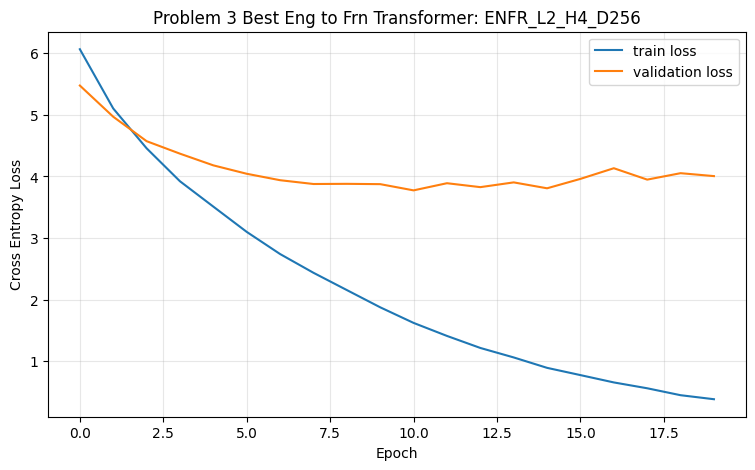

In [ ]:
best_p3_label = p3_results_df.iloc[0]["label"]
best_p3_model = p3_models[best_p3_label]
p3_gen = evaluate_translation_generation(best_p3_model, val_loader_en_fr, trg_vocab_en_fr, max_len=tcfg.max_len+10, sample_count=5)
p3_samples_df = pd.DataFrame(p3_gen["samples"])
print("Best Problem 3 model:", best_p3_label)
display(p3_samples_df)
p3_samples_df.to_csv("hw4_outputs/problem3_qualitative_samples.csv", index=False)
plot_history(p3_histories[best_p3_label], title=f"Problem 3 Best Eng to Frn Transformer: {best_p3_label}", save_path="hw4_outputs/problem3_best_loss.png")

In [ ]:
# Homework 3 reference values
example_src, _, example_trg, _, _, _ = next(iter(val_loader_en_fr))
profile_src_len_en_fr = example_src[:1].size(1)
profile_tgt_len_en_fr = example_trg[:1, :-1].size(1)

hw3_rnn_reference = pd.DataFrame([
    {"source": "HW3", "direction": "English to French", "model": "Baseline GRU", "train_loss": 0.805574, "val_loss": 6.054348, "sequence_accuracy": 0.0, "bleu4": 0.244279, "training_time_s": 13.922288, "inference_time_s": 0.155874, "params": 1527521, "model_size": 5.827030, "attention": False},
    {"source": "HW3", "direction": "English to French", "model": "Attention GRU", "train_loss": 0.143594, "val_loss": 6.183241, "sequence_accuracy": 0.0, "bleu4": 0.267756, "training_time_s": 15.865677, "inference_time_s": 0.128880, "params": 1781729, "model_size": 6.796757, "attention": True},
])

hw3_rnn_reference["flops_forward_per_sequence"] = hw3_rnn_reference["attention"].apply(
    lambda att: profile_hw3_gru_translation_flops(len(src_vocab_en_fr), len(trg_vocab_en_fr), profile_src_len_en_fr, profile_tgt_len_en_fr, attention=bool(att))
)
hw3_rnn_reference = hw3_rnn_reference.drop(columns=["attention"])

p3_best_compare = pd.concat([
    hw3_rnn_reference,
    p3_results_df.head(1).assign(source="HW4", model="Best Transformer")[["source", "direction", "model", "train_loss", "val_loss", "sequence_accuracy", "bleu4", "training_time_s", "inference_time_s", "params", "model_size", "flops_forward_per_sequence"]]
], ignore_index=True)

display(p3_best_compare)
p3_best_compare.to_csv("hw4_outputs/problem3_hw3_comparison_with_flops.csv", index=False)


,source,direction,model,train_loss,val_loss,sequence_accuracy,bleu4,training_time_s,inference_time_s,params,model_size,flops_forward_per_sequence
0,HW3,English to French,Baseline GRU,0.805574,6.054348,0.0,0.244279,13.922288,0.155874,1527521,5.827030,29244160
1,HW3,English to French,Attention GRU,0.143594,6.183241,0.0,0.267756,15.865677,0.128880,1781729,6.796757,37427968
2,HW4,English to French,Best Transformer,0.386224,4.005329,0.0,0.290086,3.473164,0.205921,4417489,16.851383,89964032


# Problem 4: Reversing the Direction to French-to-English Translation


In [ ]:
train_loader_fr_en, val_loader_fr_en, src_vocab_fr_en, trg_vocab_fr_en = make_translation_loaders(reverse=True)
batch = next(iter(train_loader_fr_en))
print("French to English batch check:", batch[0].shape, batch[2].shape)
print(batch[4][0], "->", batch[5][0])

French to English batch check: torch.Size([64, 14]) torch.Size([64, 11])
j ai recu un colis ce matin -> i received a package this morning


In [ ]:
#French to English
p4_results, p4_histories, p4_models = [], {}, {}

for cfg4 in translation_grid:
    label = f"FREN_L{cfg4['num_blocks']}_H{cfg4['num_heads']}_D{cfg4['d_model']}"
    print("\n" + "="*80)
    print("Problem 4:", label)

    # French as source and English as target.
    model = TranslationTransformer(len(src_vocab_fr_en), len(trg_vocab_fr_en), d_model=cfg4["d_model"], nhead=cfg4["num_heads"], num_layers=cfg4["num_blocks"], dropout=0.1, max_len=tcfg.max_len+10)


    history, train_time = train_translation_transformer(model, train_loader_fr_en, val_loader_fr_en, epochs=tcfg.epochs, lr=tcfg.learning_rate)
    gen_metrics = evaluate_translation_generation(model, val_loader_fr_en, trg_vocab_fr_en, max_len=tcfg.max_len+10)


    flops_forward = profile_translation_flops(model, val_loader_fr_en)

    p4_results.append({
        "problem": "P4", "direction": "French to English", "label": label,
        "num_blocks": cfg4["num_blocks"], "num_heads": cfg4["num_heads"], "d_model": cfg4["d_model"],
        "train_loss": history["train_loss"][-1], "val_loss": history["val_loss"][-1],
        "sequence_accuracy": gen_metrics["sequence_accuracy"], "bleu4": gen_metrics["bleu4"],
        "training_time_s": train_time, "inference_time_s": gen_metrics["inference_time_s"],
        "params": count_parameters(model), "model_size": model_size(model),
        "flops_forward_per_sequence": flops_forward,
    })
    p4_histories[label] = history
    p4_models[label] = model

p4_results_df = pd.DataFrame(p4_results).sort_values("bleu4", ascending=False)
display(p4_results_df)
p4_results_df.to_csv("hw4_outputs/problem4_fr_en_transformer_results.csv", index=False)



Problem 4: FREN_L1_H2_D128
Epoch 004/20 | train 4.8548 | val 4.9926
Epoch 008/20 | train 3.8366 | val 4.5064
Epoch 012/20 | train 3.1526 | val 4.3292
Epoch 016/20 | train 2.5852 | val 4.2112
Epoch 020/20 | train 2.0871 | val 4.1600

Problem 4: FREN_L1_H4_D128
Epoch 004/20 | train 4.7686 | val 5.0602
Epoch 008/20 | train 3.7344 | val 4.5134
Epoch 012/20 | train 3.0635 | val 4.2584
Epoch 016/20 | train 2.5141 | val 4.1705
Epoch 020/20 | train 2.0184 | val 4.0745

Problem 4: FREN_L2_H2_D128
Epoch 004/20 | train 4.6836 | val 4.9166
Epoch 008/20 | train 3.6175 | val 4.3765
Epoch 012/20 | train 2.8659 | val 4.1842
Epoch 016/20 | train 2.2883 | val 4.0620
Epoch 020/20 | train 1.7805 | val 3.9734

Problem 4: FREN_L2_H4_D128
Epoch 004/20 | train 4.7522 | val 4.9465
Epoch 008/20 | train 3.6933 | val 4.3480
Epoch 012/20 | train 2.9420 | val 4.1129
Epoch 016/20 | train 2.3386 | val 3.9788
Epoch 020/20 | train 1.8365 | val 3.8228

Problem 4: FREN_L4_H2_D128
Epoch 004/20 | train 4.8526 | val 5.0253

,problem,direction,label,num_blocks,num_heads,d_model,train_loss,val_loss,sequence_accuracy,bleu4,training_time_s,inference_time_s,params,model_size,flops_forward_per_sequence
6,P4,French to English,FREN_L2_H4_D256,2,4,256,0.309151,3.846242,0.009009,0.317998,3.573316,0.224414,4396158,16.770012,70981576
5,P4,French to English,FREN_L4_H4_D128,4,4,128,2.029197,3.912792,0.009009,0.267541,4.274558,0.159681,2206718,8.417961,35690128
4,P4,French to English,FREN_L4_H2_D128,4,2,128,2.075388,3.890230,0.000000,0.265144,4.281879,0.157527,2206718,8.417961,35689160
2,P4,French to English,FREN_L2_H2_D128,2,2,128,1.780515,3.973447,0.000000,0.262655,3.590319,0.171984,1281022,4.886711,19106788
3,P4,French to English,FREN_L2_H4_D128,2,4,128,1.836469,3.822810,0.000000,0.248310,3.460246,0.176429,1281022,4.886711,19107272
1,P4,French to English,FREN_L1_H4_D128,1,4,128,2.018352,4.074458,0.000000,0.212146,3.102677,0.159063,818174,3.121086,10815844
7,P4,French to English,FREN_L4_H4_D256,4,4,256,2.321893,4.248089,0.000000,0.211113,4.412942,0.322750,8082558,30.832512,136914320
0,P4,French to English,FREN_L1_H2_D128,1,2,128,2.087110,4.159971,0.000000,0.203512,2.762084,0.171028,818174,3.121086,10815602


Best Problem 4 model: FREN_L2_H4_D256


,source,target,prediction,exact_match,bleu4
0,ils nourrissent les pigeons sur la place,they feed the pigeons in the square,they feed the birds in the trees,0,0.411134
1,elle pratique le yoga tous les matins,she practices yoga every morning,she practices the cello for three hours every day,0,0.199602
2,j aime marcher dans la neige,i enjoy walking in the snow,i enjoy walking in the rain,0,0.809107
3,elle adore porter des vestes modernes,she loves to wear modern jackets,she loves to wear modern leather jackets,0,0.707107
4,le bus de la ville arrive precisement a cinq h...,the city bus arrives precisely at five o clock,the bus arrives at five o clock,0,0.461999


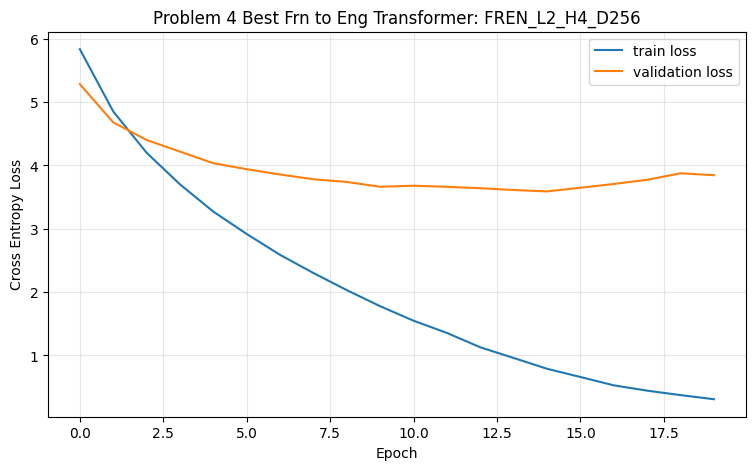

In [ ]:
best_p4_label = p4_results_df.iloc[0]["label"]
best_p4_model = p4_models[best_p4_label]
p4_gen = evaluate_translation_generation(best_p4_model, val_loader_fr_en, trg_vocab_fr_en, max_len=tcfg.max_len+10, sample_count=5)
p4_samples_df = pd.DataFrame(p4_gen["samples"])
print("Best Problem 4 model:", best_p4_label)
display(p4_samples_df)
p4_samples_df.to_csv("hw4_outputs/problem4_qualitative_samples.csv", index=False)
plot_history(p4_histories[best_p4_label], title=f"Problem 4 Best Frn to Eng Transformer: {best_p4_label}", save_path="hw4_outputs/problem4_best_loss.png")

In [ ]:
# Homework 3 RNN reference values
example_src, _, example_trg, _, _, _ = next(iter(val_loader_fr_en))
profile_src_len_fr_en = example_src[:1].size(1)
profile_tgt_len_fr_en = example_trg[:1, :-1].size(1)

hw3_rnn_reference_fr_en = pd.DataFrame([
    {"source": "HW3", "direction": "French to English", "model": "Baseline GRU", "train_loss": 1.297582, "val_loss": 6.259802, "sequence_accuracy": 0.0, "bleu4": 0.241152, "training_time_s": 13.238038, "inference_time_s": 0.095366, "params": 1501821, "model_size": 5.728992, "attention": False},
    {"source": "HW3", "direction": "French to English", "model": "Attention GRU", "train_loss": 0.122833, "val_loss": 6.587141, "sequence_accuracy": 0.0, "bleu4": 0.249977, "training_time_s": 14.565122, "inference_time_s": 0.104298, "params": 1730429, "model_size": 6.601063, "attention": True},
])

hw3_rnn_reference_fr_en["flops_forward_per_sequence"] = hw3_rnn_reference_fr_en["attention"].apply(
    lambda att: profile_hw3_gru_translation_flops(len(src_vocab_fr_en), len(trg_vocab_fr_en), profile_src_len_fr_en, profile_tgt_len_fr_en, attention=bool(att))
)
hw3_rnn_reference_fr_en = hw3_rnn_reference_fr_en.drop(columns=["attention"])

p4_best_compare = pd.concat([
    hw3_rnn_reference_fr_en,
    p4_results_df.head(1).assign(source="HW4", model="Best Transformer")[["source", "direction", "model", "train_loss", "val_loss", "sequence_accuracy", "bleu4", "training_time_s", "inference_time_s", "params", "model_size", "flops_forward_per_sequence"]]
], ignore_index=True)

display(p4_best_compare)
p4_best_compare.to_csv("hw4_outputs/problem4_hw3_comparison_with_flops.csv", index=False)


,source,direction,model,train_loss,val_loss,sequence_accuracy,bleu4,training_time_s,inference_time_s,params,model_size,flops_forward_per_sequence
0,HW3,French to English,Baseline GRU,1.297582,6.259802,0.000000,0.241152,13.238038,0.095366,1501821,5.728992,26275584
1,HW3,French to English,Attention GRU,0.122833,6.587141,0.000000,0.249977,14.565122,0.104298,1730429,6.601063,31490816
2,HW4,French to English,Best Transformer,0.309151,3.846242,0.009009,0.317998,3.573316,0.224414,4396158,16.770012,70981576


In [ ]:
#summary tables
problem1_table = p1_results_df.copy()
problem2_table = pd.concat([p2_start_df, p2_sweep_df, p2_seq50_df], ignore_index=True)
problem3_table = p3_results_df.copy()
problem4_table = p4_results_df.copy()

print("Problem 1 results")
display(problem1_table)
print("Problem 2 results")
display(problem2_table)
print("Problem 3 results")
display(problem3_table)
print("Problem 4 results")
display(problem4_table)

#missing values N/A
all_summary = pd.concat([
    problem1_table.assign(section="P1"),
    problem2_table.assign(section="P2"),
    problem3_table.assign(section="P3"),
    problem4_table.assign(section="P4"),
], ignore_index=True, sort=False)

final_columns = [
    "section", "problem", "direction", "label", "model", "seq_len",
    "d_model", "num_heads", "num_blocks",
    "train_loss", "val_loss", "val_accuracy", "sequence_accuracy", "bleu4", "val_perplexity",
    "training_time_s", "inference_time_s", "params", "model_size", "flops_forward_per_sequence",
    "sample_output_preview", "sample_output",
]


final_summary = all_summary.reindex(columns=final_columns)
final_summary_display = final_summary.copy()
final_summary_display = final_summary_display.where(pd.notna(final_summary_display), "N/A")

all_summary.to_csv("hw4_outputs/all_hw4_results_raw.csv", index=False)
final_summary_display.to_csv("hw4_outputs/all_hw4_results_final_no_nan.csv", index=False)

print("Final Homework 4 Summary Table (missing problem-specific metrics shown as N/A)")
display(final_summary_display)


Problem 1 results


,problem,model,seq_len,train_loss,val_loss,val_accuracy,val_perplexity,training_time_s,inference_time_s,params,model_size,flops_forward_per_sequence,sample_output
0,P1,Transformer LM,10,0.980275,2.660153,0.434172,14.298476,1.594927,0.115186,276525,1.054859,4152320,Next ed chors apat ate patict toctoulictovedin...
1,P1,Transformer LM,20,0.772268,3.169593,0.404737,23.797800,1.801046,0.116696,276525,1.054859,8509440,Next character. LSTM networ. Dura predictictin...
2,P1,Transformer LM,30,0.716459,3.382012,0.368710,29.429927,1.891629,0.116948,276525,1.054859,13071360,"Next Neural Networks (RNs), and s), and more s..."


Problem 2 results


,problem,label,model,seq_len,d_model,num_heads,num_blocks,train_loss,val_loss,val_accuracy,val_perplexity,training_time_s,inference_time_s,params,model_size,flops_forward_per_sequence,sample_output,sample_output_preview
0,P2,start_seq20_L2_H2,Transformer LM,20,128,2,2,1.698137,1.834461,0.469458,6.261760,100.551593,0.187430,413249,1.576420,11233280,ROMEO:\nI am not my not he heasinoureweathe.\n...,ROMEO: I am not my not he heasinoureweathe. A ...
1,P2,start_seq30_L2_H2,Transformer LM,30,128,2,2,1.663155,1.800556,0.480088,6.053012,109.068587,0.175500,413249,1.576420,17157120,"ROMEO:\nA good I die? why, they mans ge, hinof...","ROMEO: A good I die? why, they mans ge, hinofr..."
2,P2,seq30_L4_H4_D256,Transformer LM,30,256,4,4,1.297080,1.742288,0.528970,5.710395,245.463422,0.257715,3192385,12.177982,130529280,ROMEO:\nYou have pray'd to thy provy totherirt...,ROMEO: You have pray'd to thy provy totherirto...
3,P2,seq30_L4_H4_D128,Transformer LM,30,128,4,4,1.424973,1.678991,0.523786,5.360147,173.712277,0.254534,809793,3.089115,33807360,"ROMEO:\nI lay by, and having.\nO, if n anourev...","ROMEO: I lay by, and having. O, if n anourevea..."
4,P2,seq30_L4_H2_D128,Transformer LM,30,128,2,4,1.440678,1.663158,0.522156,5.275946,170.949072,0.253715,809793,3.089115,33807360,ROMEO:\nHere is not as it is hold mathe deatha...,ROMEO: Here is not as it is hold mathe deathan...
5,P2,seq30_L2_H4_D256,Transformer LM,30,256,4,2,1.533675,1.785066,0.498410,5.959973,145.052480,0.199226,1612865,6.152592,65771520,ROMEO:\nIs am any these woord with arithonofou...,ROMEO: Is am any these woord with arithonofour...
6,P2,seq30_L2_H4_D128,Transformer LM,30,128,4,2,1.627669,1.786163,0.483932,5.966515,112.786343,0.174031,413249,1.576420,17157120,"ROMEO:\nThy arth, will say do for henorireminu...","ROMEO: Thy arth, will say do for henorireminug..."
7,P2,seq30_L2_H2_D128,Transformer LM,30,128,2,2,1.664223,1.813545,0.478236,6.132148,111.065374,0.174441,413249,1.576420,17157120,"ROMEO:\nTheir before fearewell, scaleleanderea...","ROMEO: Their before fearewell, scaleleanderear..."
8,P2,seq30_L1_H4_D128,Transformer LM,30,128,4,1,2.183904,2.269738,0.344367,9.676862,79.685264,0.134363,214977,0.820072,8832000,ROMEO:\nNay gought theant lllieainde Whire ath...,ROMEO: Nay gought theant lllieainde Whire athe...
9,P2,seq30_L1_H2_D128,Transformer LM,30,128,2,1,2.271272,2.380312,0.307586,10.808278,77.531906,0.132836,214977,0.820072,8832000,"ROMEO:\nFordom the LO:\nLore here thathe, w y ...","ROMEO: Fordom the LO: Lore here thathe, w y st..."


Problem 3 results


,problem,direction,label,num_blocks,num_heads,d_model,train_loss,val_loss,sequence_accuracy,bleu4,training_time_s,inference_time_s,params,model_size,flops_forward_per_sequence
6,P3,English to French,ENFR_L2_H4_D256,2,4,256,0.386224,4.005329,0.000000,0.290086,3.473164,0.205921,4417489,16.851383,89964032
7,P3,English to French,ENFR_L4_H4_D256,4,4,256,1.781792,4.125107,0.009009,0.254168,4.329573,0.267392,8103889,30.913883,171910656
3,P3,English to French,ENFR_L2_H4_D128,2,4,128,1.934523,3.911968,0.000000,0.238957,3.047925,0.108233,1291729,4.927555,24666880
2,P3,English to French,ENFR_L2_H2_D128,2,2,128,2.005498,3.969085,0.000000,0.236207,3.025188,0.201196,1291729,4.927555,24665856
4,P3,English to French,ENFR_L4_H2_D128,4,2,128,2.191536,3.885640,0.000000,0.229941,3.940479,0.173908,2217425,8.458805,45323008
5,P3,English to French,ENFR_L4_H4_D128,4,4,128,2.189940,3.930416,0.000000,0.224709,4.066479,0.255862,2217425,8.458805,45325056
1,P3,English to French,ENFR_L1_H4_D128,1,4,128,2.243525,4.100421,0.000000,0.209308,2.744062,0.169488,828881,3.161930,14337792
0,P3,English to French,ENFR_L1_H2_D128,1,2,128,2.285860,4.140731,0.000000,0.196959,2.744469,0.198889,828881,3.161930,14337280


Problem 4 results


,problem,direction,label,num_blocks,num_heads,d_model,train_loss,val_loss,sequence_accuracy,bleu4,training_time_s,inference_time_s,params,model_size,flops_forward_per_sequence
6,P4,French to English,FREN_L2_H4_D256,2,4,256,0.309151,3.846242,0.009009,0.317998,3.573316,0.224414,4396158,16.770012,70981576
5,P4,French to English,FREN_L4_H4_D128,4,4,128,2.029197,3.912792,0.009009,0.267541,4.274558,0.159681,2206718,8.417961,35690128
4,P4,French to English,FREN_L4_H2_D128,4,2,128,2.075388,3.890230,0.000000,0.265144,4.281879,0.157527,2206718,8.417961,35689160
2,P4,French to English,FREN_L2_H2_D128,2,2,128,1.780515,3.973447,0.000000,0.262655,3.590319,0.171984,1281022,4.886711,19106788
3,P4,French to English,FREN_L2_H4_D128,2,4,128,1.836469,3.822810,0.000000,0.248310,3.460246,0.176429,1281022,4.886711,19107272
1,P4,French to English,FREN_L1_H4_D128,1,4,128,2.018352,4.074458,0.000000,0.212146,3.102677,0.159063,818174,3.121086,10815844
7,P4,French to English,FREN_L4_H4_D256,4,4,256,2.321893,4.248089,0.000000,0.211113,4.412942,0.322750,8082558,30.832512,136914320
0,P4,French to English,FREN_L1_H2_D128,1,2,128,2.087110,4.159971,0.000000,0.203512,2.762084,0.171028,818174,3.121086,10815602


Final Homework 4 Summary Table (missing problem-specific metrics shown as N/A)


,section,problem,direction,label,model,seq_len,d_model,num_heads,num_blocks,train_loss,...,sequence_accuracy,bleu4,val_perplexity,training_time_s,inference_time_s,params,model_size,flops_forward_per_sequence,sample_output_preview,sample_output
0,P1,P1,N/A,N/A,Transformer LM,10.0,N/A,N/A,N/A,0.980275,...,N/A,N/A,14.298476,1.594927,0.115186,276525,1.054859,4152320,N/A,Next ed chors apat ate patict toctoulictovedin...
1,P1,P1,N/A,N/A,Transformer LM,20.0,N/A,N/A,N/A,0.772268,...,N/A,N/A,23.7978,1.801046,0.116696,276525,1.054859,8509440,N/A,Next character. LSTM networ. Dura predictictin...
2,P1,P1,N/A,N/A,Transformer LM,30.0,N/A,N/A,N/A,0.716459,...,N/A,N/A,29.429927,1.891629,0.116948,276525,1.054859,13071360,N/A,"Next Neural Networks (RNs), and s), and more s..."
3,P2,P2,N/A,start_seq20_L2_H2,Transformer LM,20.0,128.0,2.0,2.0,1.698137,...,N/A,N/A,6.26176,100.551593,0.187430,413249,1.576420,11233280,ROMEO: I am not my not he heasinoureweathe. A ...,ROMEO:\nI am not my not he heasinoureweathe.\n...
4,P2,P2,N/A,start_seq30_L2_H2,Transformer LM,30.0,128.0,2.0,2.0,1.663155,...,N/A,N/A,6.053012,109.068587,0.175500,413249,1.576420,17157120,"ROMEO: A good I die? why, they mans ge, hinofr...","ROMEO:\nA good I die? why, they mans ge, hinof..."
5,P2,P2,N/A,seq30_L4_H4_D256,Transformer LM,30.0,256.0,4.0,4.0,1.297080,...,N/A,N/A,5.710395,245.463422,0.257715,3192385,12.177982,130529280,ROMEO: You have pray'd to thy provy totherirto...,ROMEO:\nYou have pray'd to thy provy totherirt...
6,P2,P2,N/A,seq30_L4_H4_D128,Transformer LM,30.0,128.0,4.0,4.0,1.424973,...,N/A,N/A,5.360147,173.712277,0.254534,809793,3.089115,33807360,"ROMEO: I lay by, and having. O, if n anourevea...","ROMEO:\nI lay by, and having.\nO, if n anourev..."
7,P2,P2,N/A,seq30_L4_H2_D128,Transformer LM,30.0,128.0,2.0,4.0,1.440678,...,N/A,N/A,5.275946,170.949072,0.253715,809793,3.089115,33807360,ROMEO: Here is not as it is hold mathe deathan...,ROMEO:\nHere is not as it is hold mathe deatha...
8,P2,P2,N/A,seq30_L2_H4_D256,Transformer LM,30.0,256.0,4.0,2.0,1.533675,...,N/A,N/A,5.959973,145.052480,0.199226,1612865,6.152592,65771520,ROMEO: Is am any these woord with arithonofour...,ROMEO:\nIs am any these woord with arithonofou...
9,P2,P2,N/A,seq30_L2_H4_D128,Transformer LM,30.0,128.0,4.0,2.0,1.627669,...,N/A,N/A,5.966515,112.786343,0.174031,413249,1.576420,17157120,"ROMEO: Thy arth, will say do for henorireminug...","ROMEO:\nThy arth, will say do for henorireminu..."
